**Iterative Workflow**

In [23]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv


In [24]:
load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.1,
    max_retries=2,
)

In [25]:
# Structured output for the Critic
class Critique(BaseModel):
    score: int = Field(description="Score from 1-10", ge=1, le=10)
    suggestions: str = Field(description="Feedback to improve the text")
    is_good_enough: bool = Field(description="True if score >= 5")

In [26]:
class IterativeState(TypedDict):
    task: str
    draft: str
    critique: str
    iterations: int
    max_iterations: int
    score: int
    is_good_enough: bool

In [27]:
critic_llm = llm.with_structured_output(Critique)

In [28]:
def writer_node(state: IterativeState):
    """Generates or improves the draft based on feedback."""
    iterations = state.get("iterations", 0)
    
    if iterations == 0:
        prompt = f"Write a short technical paragraph about: {state['task']}"
    else:
        prompt = (
            f"Improve this draft: {state['draft']}\n\n"
            f"Based on this feedback: {state['critique']}\n"
            f"Make it more professional and detailed."
        )
    
    response = llm.invoke(prompt).content
    return {"draft": response, "iterations": iterations + 1}

def critic_node(state: IterativeState):
    """Evaluates the draft and provides structured feedback."""
    prompt = f"Critique this text and provide a score out of 10: {state['draft']}"
    result = critic_llm.invoke(prompt)
    
    return {
        "critique": result.suggestions,
        "is_good_enough": result.is_good_enough,
        "score": result.score
    }

In [29]:
#Router
def should_continue(state: IterativeState) -> Literal["repeat", "end"]:
    # Exit if quality is met OR we hit the safety limit
    if state.get("is_good_enough") or state["iterations"] >= state["max_iterations"]:
        return "end"
    return "repeat"

In [30]:
builder = StateGraph(IterativeState)

builder.add_node("writer", writer_node)
builder.add_node("critic", critic_node)

builder.add_edge(START, "writer")
builder.add_edge("writer", "critic")

# The Iterative Loop
builder.add_conditional_edges(
    "critic",
    should_continue,
    {
        "repeat": "writer",
        "end": END
    }
)

graph = builder.compile()

In [31]:
initial_input = {
    "task": "Explain why Redux Toolkit is better than Vanilla Redux",
    "max_iterations": 3,
    "iterations": 0
}

# Using .stream to see the iterations happening in real-time
for chunk in graph.stream(initial_input):
    for node, values in chunk.items():
        print(f"--- Node: {node} ---")
        if "draft" in values:
            print(f"Draft Length: {len(values['draft'])} chars")
        if "score" in values:
            print(f"Current Score: {values['score']}/10")

--- Node: writer ---
Draft Length: 803 chars
--- Node: critic ---
Current Score: 9/10


In [32]:
inputs = {"task": "Explain WebSockets", "max_iterations": 3, "iterations": 0}

# .stream() returns a generator of updates
for chunk in graph.stream(inputs):
    for node_name, state_update in chunk.items():
        print(f"\n--- Node: {node_name} ---")
        # state_update contains only the keys returned by that specific node
        print(state_update)


--- Node: writer ---
{'draft': "WebSockets is a bi-directional, real-time communication protocol that enables a persistent, low-latency connection between a client's web browser and a server over the web. Unlike traditional HTTP requests, which are unidirectional and require a new connection for each request, WebSockets establish a single, persistent connection that allows for simultaneous, two-way communication. This is achieved through a handshake process, where the client initiates a WebSocket connection by sending an HTTP request to the server, which then upgrades the connection to a WebSocket protocol. Once established, the WebSocket connection allows for the exchange of data in real-time, enabling applications such as live updates, collaborative editing, and real-time gaming, with the server able to push data to the client without requiring a request, and the client able to send data to the server at any time.", 'iterations': 1}

--- Node: critic ---
{'critique': "The text is we

In [22]:
final_state = graph.invoke(inputs)

# Access specific keys
print(f"Final Score: {final_state.get('score')}")
print(f"Final Draft: {final_state['draft']}")

# See all keys currently in the state
print(f"All State Keys: {final_state.keys()}")

Final Score: None
Final Draft: **Introduction to WebSockets: Enabling Real-Time Communication**

WebSockets is a bi-directional, real-time communication protocol that facilitates a persistent, low-latency connection between a client's web browser and a server over the web. This protocol enables the establishment of a single, persistent connection, allowing both the client and server to send and receive data simultaneously, thereby reducing the overhead associated with traditional HTTP requests. In contrast to traditional HTTP requests, which establish a new connection for each request, WebSockets provide a more efficient and scalable solution for real-time communication, making them an essential tool for modern web development.

The WebSocket protocol is based on the TCP/IP protocol and uses the HTTP protocol to establish the initial connection. Once the connection is established, the WebSocket protocol takes over, allowing for bi-directional, real-time communication between the client

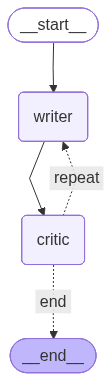

In [33]:

from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())